In [177]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
import seaborn as sns
import tensorflow as tf
from arch.unitroot import KPSS

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import mean_squared_error


In [178]:
def acf1(x, nlags=None, acf_type='correlation', pacf=False, ax=None, return_values=False, **kwargs):
    """
    Calculate and optionally plot the autocorrelation or partial autocorrelation function.

    Parameters:
    - x: Input time series.
    - nlags: Number of lags to compute.
    - acf_type: 'correlation' for autocorrelation, 'covariance' for autocovariance.
    - pacf: If True, computes partial autocorrelation instead of autocorrelation.
    - ax: Matplotlib axis to plot on. If None, a new axis is created.
    - return_values: If True, the function will return the ACF/PACF values and lags.
    - **kwargs: Additional keyword arguments for the plot.

    Returns:
    - If return_values is True, returns (lags, values).
    """
    lags = np.arange(1, nlags + 1)

    if pacf:
        if acf_type == 'correlation':
            values = sm.tsa.pacf(x, nlags=nlags)[1:]
            ylabel = 'PACF'
    else:
        if acf_type == 'correlation':
            values = sm.tsa.acf(x, nlags=nlags, fft=False)[1:]
            ylabel = 'ACF'
        elif acf_type == 'covariance':
            values = sm.tsa.acovf(x, nlag=nlags)[1:]
            ylabel = 'ACoV'

    if return_values:
        return lags, values

    if ax is None:
        ax = plt.gca()

    ax.bar(lags, values, **kwargs)
    ax.axhline(0, color='black', linewidth=1)
    if acf_type == 'correlation':
        conf_level = 1.96 / np.sqrt(x.shape[0])
        ax.axhline(conf_level, color='red', linestyle='--', linewidth=1)
        ax.axhline(-conf_level, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('LAG')
    ax.set_ylabel(ylabel)

    return ax

In [179]:
# Read the dataset

X = pd.read_csv("../data/processed/tourism_long.csv",
                parse_dates=["date"])

X.head()

,date,state,arrivals,overnight
0,1992-01-01,Baden-Württemberg,600440.0,2217561.0
1,1992-02-01,Baden-Württemberg,721432.0,2463814.0
2,1992-03-01,Baden-Württemberg,813015.0,2788980.0
3,1992-04-01,Baden-Württemberg,973059.0,3363530.0
4,1992-05-01,Baden-Württemberg,1229069.0,4079477.0


In [180]:
X.tail()

,date,state,arrivals,overnight
6523,2025-08-01,Thüringen,436547.0,1173710.0
6524,2025-09-01,Thüringen,388441.0,966075.0
6525,2025-10-01,Thüringen,365169.0,951976.0
6526,2025-11-01,Thüringen,286528.0,703055.0
6527,2025-12-01,Thüringen,270557.0,680998.0


In [181]:
# Show all unique state names

states = X["state"].unique()

print("Number of states:", len(states))
print("States:")
print(states)

Number of states: 16
States:
['Baden-Württemberg' 'Bayern' 'Berlin' 'Brandenburg' 'Bremen' 'Hamburg'
 'Hessen' 'Mecklenburg-Vorpommern' 'Niedersachsen' 'Nordrhein-Westfalen'
 'Rheinland-Pfalz' 'Saarland' 'Sachsen' 'Sachsen-Anhalt'
 'Schleswig-Holstein' 'Thüringen']


In [182]:
# Select state

state_name = "Berlin"

In [183]:
# Create time series for selected state

X_state = X[X["state"] == state_name].set_index("date")

x_ts = pd.Series(
    X_state["arrivals"].values,
    index=X_state.index
)

# Ensure monthly frequency
x_ts = x_ts.asfreq("MS")

x_ts.head()

date
1992-01-01    186026.0
1992-02-01    199740.0
1992-03-01    264394.0
1992-04-01    273840.0
1992-05-01    326736.0
Freq: MS, dtype: float64

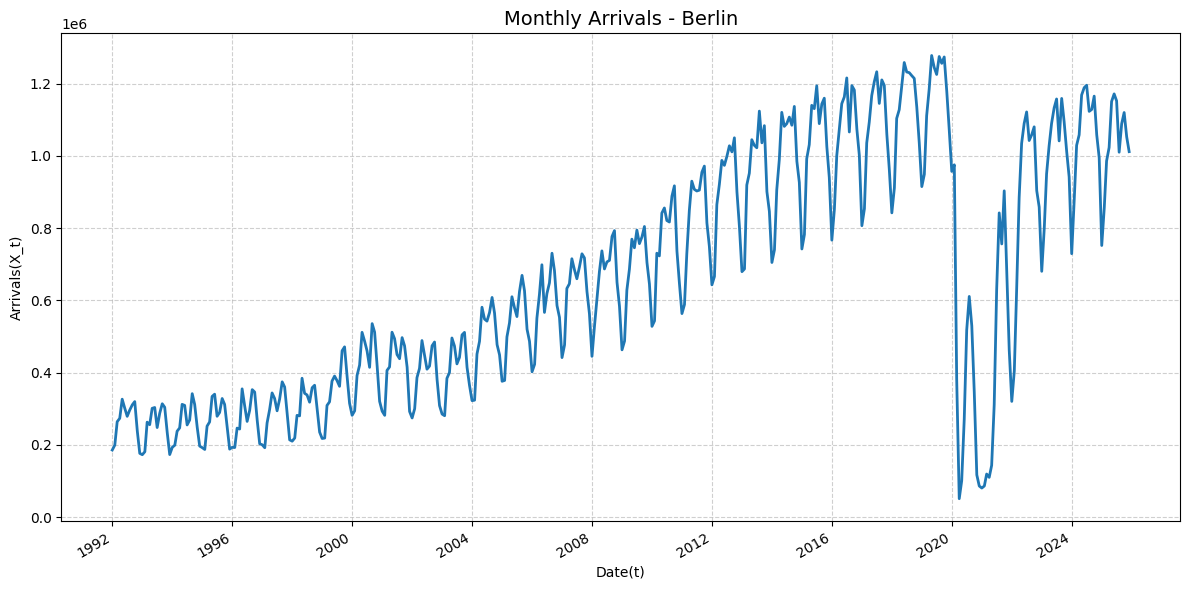

In [184]:
# Time series plot of X_t (enhanced version)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(x_ts, linewidth=2)

ax.set_title(f"Monthly Arrivals - {state_name}", fontsize=14)
ax.set_xlabel("Date(t)")
ax.set_ylabel("Arrivals(X_t)")

ax.grid(True, linestyle="--", alpha=0.6)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [185]:
# Test the stationarity of X_t

# Perform KPSS test
kpss_test = KPSS(x_ts)
p_value = kpss_test.pvalue

# Print the results
print(f'p-value: {p_value:.3f}\n')

# Interpret the results
alpha = 0.05
if p_value >= alpha:
     print(f'The time series is stationary (fail to reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')
else: 
    print(f'The time series is not stationary (reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')

p-value: 0.000

The time series is not stationary (reject "H0: The time series is stationary" at a 5% significance level).


/var/folders/2_/4gjpcdfn1xv5133yqx63q_wc0000gn/T/ipykernel_87377/1503179283.py:4: DeprecationWarning: Lag selection has changed to use a data-dependent method. To use the old method that only depends on time, set lags=-1
  kpss_test = KPSS(x_ts)


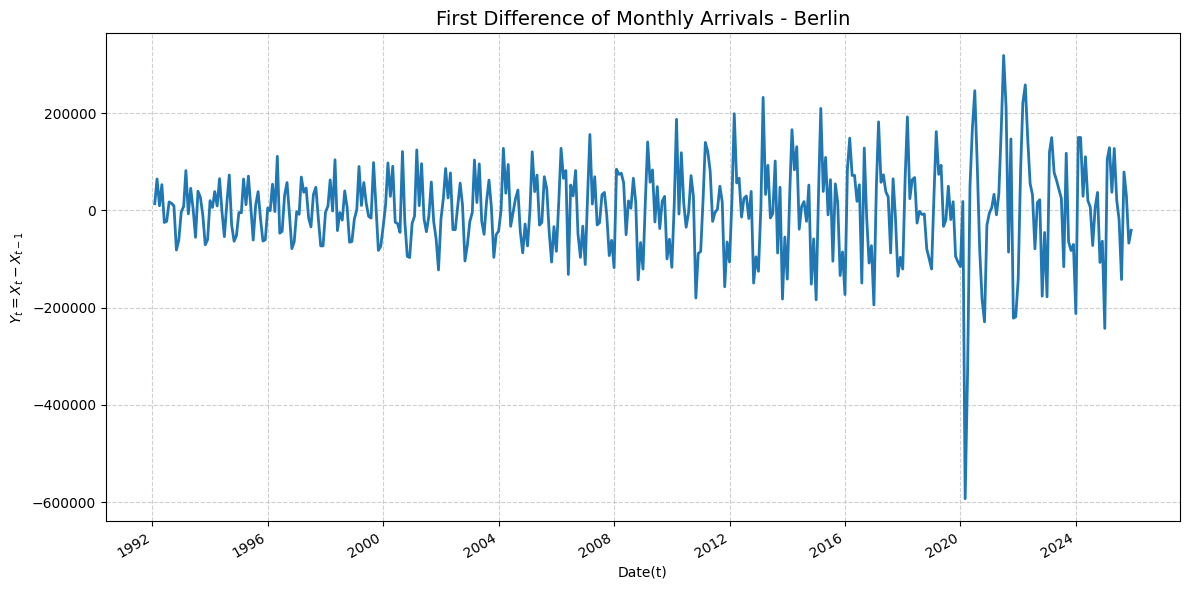

In [186]:
# Time series plot of Y_t := X_t - X_{t-1}

y_ts = x_ts.diff().dropna()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(y_ts, linewidth=2)

ax.set_title(f"First Difference of Monthly Arrivals - {state_name}", fontsize=14)
ax.set_xlabel("Date(t)")
ax.set_ylabel(r"$Y_t = X_t - X_{t-1}$")

ax.grid(True, linestyle="--", alpha=0.6)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [187]:
# Test the stationarity of Y_t

# Perform KPSS test
kpss_test = KPSS(y_ts)
p_value = kpss_test.pvalue

# Print the results
print(f'p-value: {p_value:.3f}\n')

# Interpret the results
alpha = 0.05
if p_value >= alpha:
     print(f'The time series is stationary (fail to reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')
else: 
    print(f'The time series is not stationary (reject "H0: The time series is stationary" at a {100*alpha:.0f}% significance level).')


p-value: 0.996

The time series is stationary (fail to reject "H0: The time series is stationary" at a 5% significance level).


/var/folders/2_/4gjpcdfn1xv5133yqx63q_wc0000gn/T/ipykernel_87377/1163362364.py:4: DeprecationWarning: Lag selection has changed to use a data-dependent method. To use the old method that only depends on time, set lags=-1
  kpss_test = KPSS(y_ts)


In [188]:
# Split last 12 months as test set

# Training set (log-level)
u1_ts = x_ts.iloc[:-12]

# Test set (log-level)
u2_ts = x_ts.iloc[-12:]

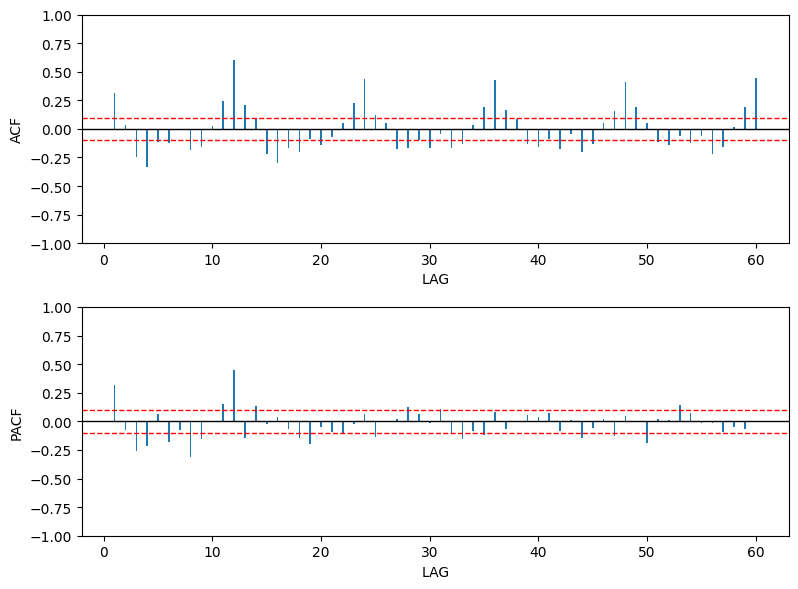

In [189]:
# Plot ACF amd PACF for (1-B)U1_t

fig, axes = plt.subplots(nrows = 2, figsize = (8,6))

acf1(u1_ts.diff().dropna(), nlags = 60, ax = axes[0], width = 0.15)
axes[0].set_ylim(-1, 1)

acf1(u1_ts.diff().dropna(), nlags = 60, ax = axes[1], width = 0.15, pacf = True)
axes[1].set_ylim(-1, 1)

fig.tight_layout()
plt.show()

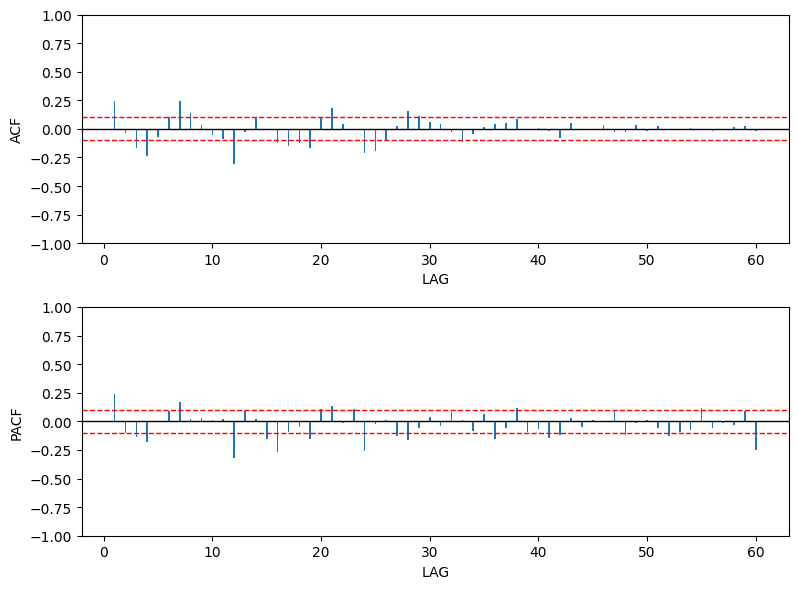

In [190]:
# Plot ACF amd PACF for (1-B^{12})(1-B)U1_t

fig, axes = plt.subplots(nrows = 2, figsize = (8,6))

acf1(u1_ts.diff().dropna().diff(12).dropna(), nlags = 60, ax = axes[0], width = 0.15)
axes[0].set_ylim(-1, 1)

acf1(u1_ts.diff().dropna().diff(12).dropna(), nlags = 60, ax = axes[1], width = 0.15, pacf = True)
axes[1].set_ylim(-1, 1)

fig.tight_layout()
plt.show()


## 1. SARIMA Model

In [191]:
# Fit a SARIMA(1,1,1)(1,1,1)_{12} model to U1_t

model1 = sm.tsa.arima.ARIMA(u1_ts, order=(2, 1, 2), seasonal_order=(1, 1, 1, 12)).fit(method_kwargs={'maxiter': 500})
print(model1.summary())

#method_kwargs={'maxiter': 500}

                                     SARIMAX Results                                      
Dep. Variable:                               None   No. Observations:                  396
Model:             ARIMA(2, 1, 2)x(1, 1, [1], 12)   Log Likelihood               -4790.112
Date:                            Thu, 05 Mar 2026   AIC                           9594.223
Time:                                    17:14:14   BIC                           9621.859
Sample:                                01-01-1992   HQIC                          9605.186
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0735      0.090     11.897      0.000       0.897       1.250
ar.L2         -0.7963      0.084   

In [192]:
model1.mle_retvals['converged']

True

In [193]:
# Fit a SARIMA(4,1,5)(1,1,1)_{12} model to U1_t

model2 = sm.tsa.arima.ARIMA(u1_ts, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit()
print(model2.summary())

                                    SARIMAX Results                                     
Dep. Variable:                             None   No. Observations:                  396
Model:             ARIMA(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -4802.269
Date:                          Thu, 05 Mar 2026   AIC                           9614.537
Time:                                  17:14:25   BIC                           9634.277
Sample:                              01-01-1992   HQIC                          9622.368
                                   - 12-01-2024                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0213      0.335      0.064      0.949      -0.636       0.678
ma.L1          0.2240      0.334      0.671      0.

In [36]:
model2.mle_retvals['converged']

True

In [194]:
model3 = sm.tsa.arima.ARIMA(u1_ts, order=(0, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(method_kwargs={'maxiter': 500})
print(model3.summary())

                                    SARIMAX Results                                     
Dep. Variable:                             None   No. Observations:                  396
Model:             ARIMA(0, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -4802.314
Date:                          Thu, 05 Mar 2026   AIC                           9612.628
Time:                                  17:14:40   BIC                           9628.420
Sample:                              01-01-1992   HQIC                          9618.892
                                   - 12-01-2024                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.2437      0.034      7.224      0.000       0.178       0.310
ar.S.L12       0.2127      0.061      3.475      0.

In [230]:
# Forecast and confidence boundaries

k = 12 # Number of steps to forecast
u1_ts_preds = model1.get_forecast(steps = k)

# Extract the confidence intervals
conf_int = u1_ts_preds.conf_int()

# Create a DataFrame
sarima_df = pd.DataFrame({
    'predicted_mean': u1_ts_preds.predicted_mean,
    'lower_ci': conf_int.iloc[:, 0],
    'upper_ci': conf_int.iloc[:, 1]
})


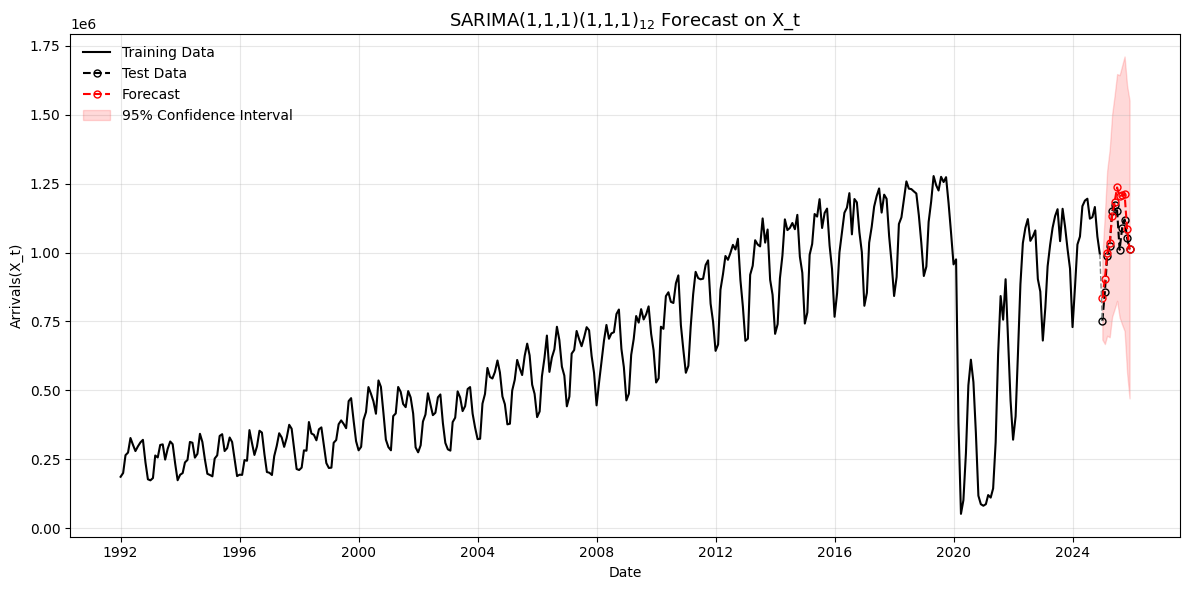

In [231]:
# Plot: Train, Test, Forecast with Confidence Interval

plt.figure(figsize=(12, 6))

# Training data
plt.plot(u1_ts, color='black', linewidth=1.5, label='Training Data')

# Test data
plt.plot(u2_ts, color='black', linestyle='--', marker='o',
         markerfacecolor='none', markersize=5, label='Test Data')

# Forecast
plt.plot(sarima_df['predicted_mean'], color='red',
         linestyle='--', marker='o', markersize=5,
         markerfacecolor='none', label='Forecast')

# Confidence interval
plt.fill_between(
    sarima_df.index,
    sarima_df['lower_ci'],
    sarima_df['upper_ci'],
    color='red',
    alpha=0.15,
    label='95% Confidence Interval'
)

# Connect last train point to first test point
plt.plot(
    [u1_ts.index[-1], u2_ts.index[0]],
    [u1_ts.iloc[-1], u2_ts.iloc[0]],
    linestyle='--',
    color='gray',
    linewidth=1
)

plt.title('SARIMA(1,1,1)(1,1,1)$_{12}$ Forecast on X_t', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Arrivals(X_t)')

plt.grid(alpha=0.3)
plt.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

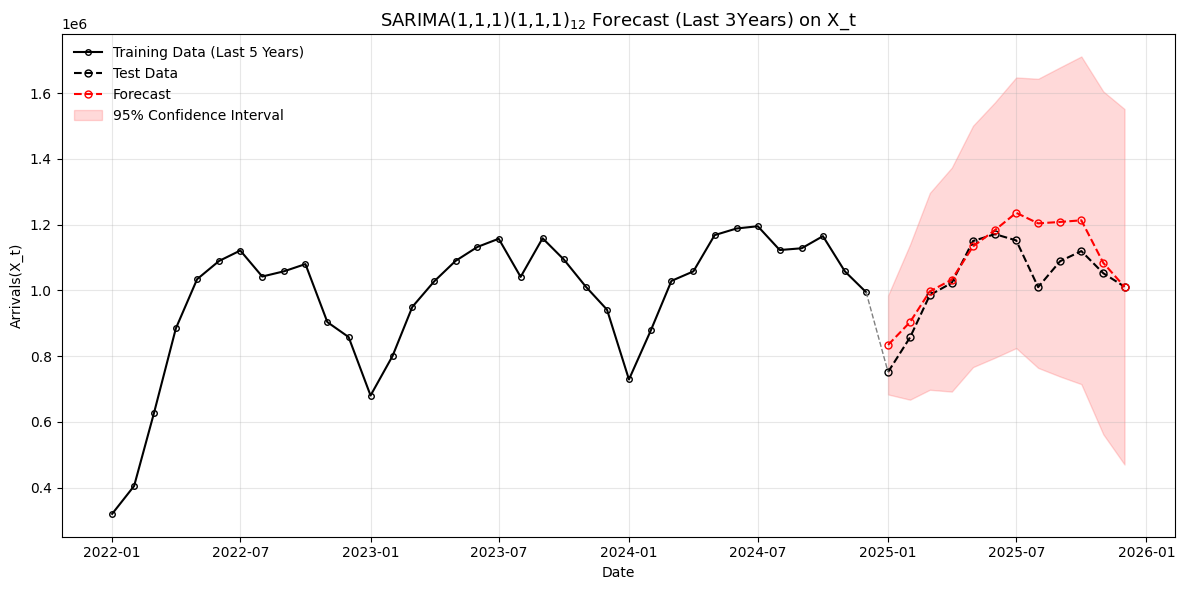

In [232]:
# Plot: Last 3 Years (Zoomed View)

plt.figure(figsize=(12, 6))

# Training data (last 36 months)
plt.plot(
    u1_ts.index[-36:],
    u1_ts[-36:],
    color='black',
    linewidth=1.5,
    marker='o',
    markersize=4,
    markerfacecolor='none',
    label='Training Data (Last 5 Years)'
)

# Test data
plt.plot(
    u2_ts,
    color='black',
    linestyle='--',
    marker='o',
    markersize=5,
    markerfacecolor='none',
    label='Test Data'
)

# Forecast
plt.plot(
    sarima_df['predicted_mean'],
    color='red',
    linestyle='--',
    marker='o',
    markersize=5,
    markerfacecolor='none',
    label='Forecast'
)

# Confidence Interval
plt.fill_between(
    sarima_df.index,
    sarima_df['lower_ci'],
    sarima_df['upper_ci'],
    color='red',
    alpha=0.15,
    label='95% Confidence Interval'
)

# Connect last train to first test
plt.plot(
    [u1_ts.index[-1], u2_ts.index[0]],
    [u1_ts.iloc[-1], u2_ts.iloc[0]],
    linestyle='--',
    color='gray',
    linewidth=1
)

plt.title('SARIMA(1,1,1)(1,1,1)$_{12}$ Forecast (Last 3Years) on X_t', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Arrivals(X_t)')

plt.grid(alpha=0.3)
plt.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

In [233]:
# Convert to original scale
actual = u2_ts
forecast = sarima_df['predicted_mean']

# Align indices
actual, forecast = actual.align(forecast, join='inner')

# MAPE
errors_pct = np.abs((actual - forecast) / actual)
mape = np.mean(errors_pct) * 100

# RMSE
errors = actual - forecast
rmse = np.sqrt(np.mean(errors**2))

print("Forecast Evaluation on Test Set")
print("-" * 40)
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Root Mean Squared Error (RMSE): {rmse:,.0f}")
print("-" * 40)

print("\nInterpretation:")
print(f"→ On average, the model's forecasts deviate by approximately {mape:.2f}% from the true values.")
print(f"→ The typical absolute forecasting error is around {rmse:,.0f} arrivals per month.")

Forecast Evaluation on Test Set
----------------------------------------
Mean Absolute Percentage Error (MAPE): 5.82%
Root Mean Squared Error (RMSE): 80,805
----------------------------------------

Interpretation:
→ On average, the model's forecasts deviate by approximately 5.82% from the true values.
→ The typical absolute forecasting error is around 80,805 arrivals per month.


## 2. SARIMAX Model (with corona dummy)

In [234]:
# Create corona dummy for full series

corona_dummy = (
    (x_ts.index >= "2020-03-01") &
    (x_ts.index <= "2021-05-01")
).astype(int)

In [235]:
# Create corona dummy as a pandas Series aligned with x_ts index
corona_dummy = pd.Series(
    ((x_ts.index >= "2020-03-01") &
     (x_ts.index <= "2021-05-01")).astype(int),
    index=x_ts.index,
    name='corona_dummy'
)

# Split exogenous variable into train and test
exog_train = corona_dummy.iloc[:-12]
exog_test  = corona_dummy.iloc[-12:]

In [223]:
print(exog_train.sum())

15


In [236]:
model_exog = sm.tsa.arima.ARIMA( u1_ts, order=(2,1,2), seasonal_order=(1,1,1,12), exog=exog_train).fit(method_kwargs={'maxiter': 500})

print(model_exog.summary())
#method_kwargs={'maxiter': 500}

                                     SARIMAX Results                                      
Dep. Variable:                               None   No. Observations:                  396
Model:             ARIMA(2, 1, 2)x(1, 1, [1], 12)   Log Likelihood               -4739.126
Date:                            Thu, 05 Mar 2026   AIC                           9494.252
Time:                                    17:19:34   BIC                           9525.836
Sample:                                01-01-1992   HQIC                          9506.781
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
corona_dummy -3.726e+05    1.1e+04    -34.009      0.000   -3.94e+05   -3.51e+05
ar.L1            1.2081      

In [237]:
# Forecast and confidence boundaries with exogenous variable

k = 12  # Number of steps to forecast

u1_ts_preds = model_exog.get_forecast( steps=k, exog=exog_test)

# Extract the confidence intervals
conf_int = u1_ts_preds.conf_int()

# Create a DataFrame
sarimax_df = pd.DataFrame({
    'predicted_mean': u1_ts_preds.predicted_mean,
    'lower_ci': conf_int.iloc[:, 0],
    'upper_ci': conf_int.iloc[:, 1]
})

In [238]:
exog_test.sum()

0

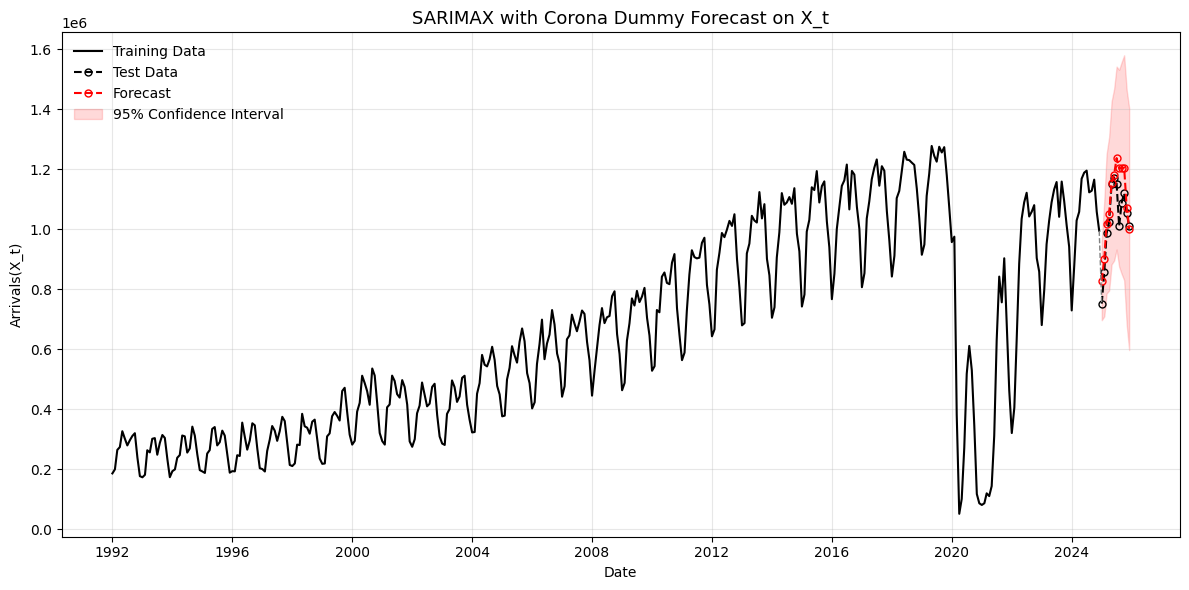

In [239]:
# Plot: Train, Test, Forecast with Confidence Interval

plt.figure(figsize=(12, 6))

# Training data
plt.plot(u1_ts, color='black', linewidth=1.5, label='Training Data')

# Test data
plt.plot(u2_ts, color='black', linestyle='--', marker='o',
         markerfacecolor='none', markersize=5, label='Test Data')

# Forecast
plt.plot(sarimax_df['predicted_mean'], color='red',
         linestyle='--', marker='o', markersize=5,
         markerfacecolor='none', label='Forecast')

# Confidence interval
plt.fill_between(
    sarimax_df.index,
    sarimax_df['lower_ci'],
    sarimax_df['upper_ci'],
    color='red',
    alpha=0.15,
    label='95% Confidence Interval'
)

# Connect last train point to first test point
plt.plot(
    [u1_ts.index[-1], u2_ts.index[0]],
    [u1_ts.iloc[-1], u2_ts.iloc[0]],
    linestyle='--',
    color='gray',
    linewidth=1
)

plt.title('SARIMAX with Corona Dummy Forecast on X_t', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Arrivals(X_t)')

plt.grid(alpha=0.3)
plt.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

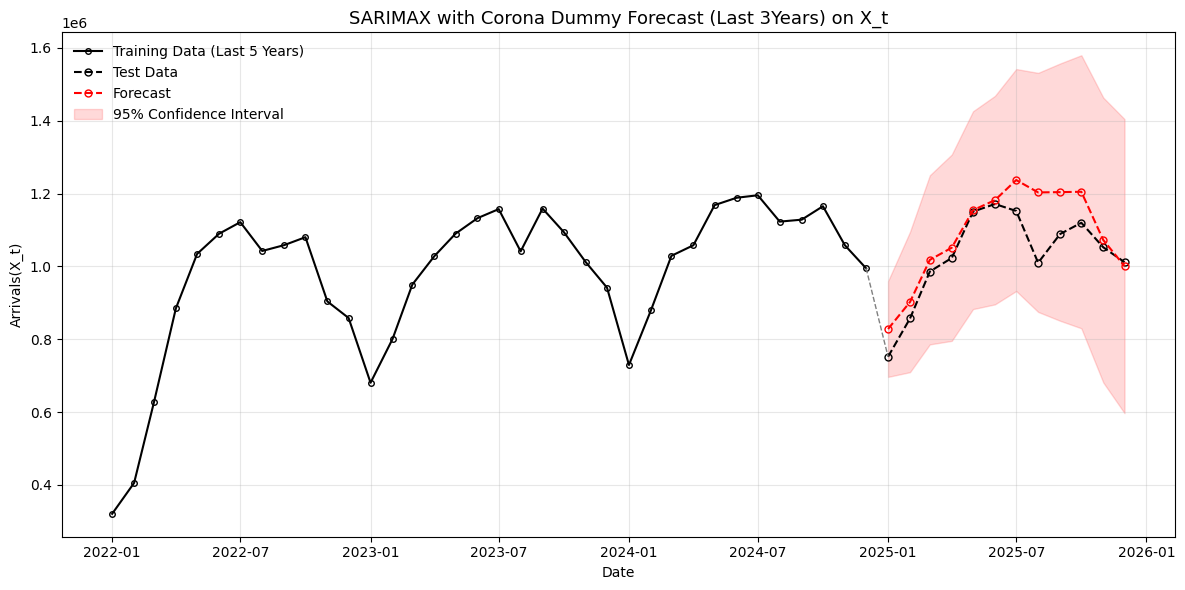

In [240]:
# Plot: Last 3 Years (Zoomed View)

plt.figure(figsize=(12, 6))

# Training data (last 36 months)
plt.plot(
    u1_ts.index[-36:],
    u1_ts[-36:],
    color='black',
    linewidth=1.5,
    marker='o',
    markersize=4,
    markerfacecolor='none',
    label='Training Data (Last 5 Years)'
)

# Test data
plt.plot(
    u2_ts,
    color='black',
    linestyle='--',
    marker='o',
    markersize=5,
    markerfacecolor='none',
    label='Test Data'
)

# Forecast
plt.plot(
    sarimax_df['predicted_mean'],
    color='red',
    linestyle='--',
    marker='o',
    markersize=5,
    markerfacecolor='none',
    label='Forecast'
)

# Confidence Interval
plt.fill_between(
    sarimax_df.index,
    sarimax_df['lower_ci'],
    sarimax_df['upper_ci'],
    color='red',
    alpha=0.15,
    label='95% Confidence Interval'
)

# Connect last train to first test
plt.plot(
    [u1_ts.index[-1], u2_ts.index[0]],
    [u1_ts.iloc[-1], u2_ts.iloc[0]],
    linestyle='--',
    color='gray',
    linewidth=1
)

plt.title('SARIMAX with Corona Dummy Forecast (Last 3Years) on X_t', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Arrivals(X_t)')

plt.grid(alpha=0.3)
plt.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

In [241]:
# Convert to original scale
actual = u2_ts
forecast = sarimax_df['predicted_mean']

# Align indices
actual, forecast = actual.align(forecast, join='inner')

# MAPE
errors_pct = np.abs((actual - forecast) / actual)
mape = np.mean(errors_pct) * 100

# RMSE
errors = actual - forecast
rmse = np.sqrt(np.mean(errors**2))

print("Forecast Evaluation on Test Set")
print("-" * 40)
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"Root Mean Squared Error (RMSE): {rmse:,.0f}")
print("-" * 40)

print("\nInterpretation:")
print(f"→ On average, the model's forecasts deviate by approximately {mape:.2f}% from the true values.")
print(f"→ The typical absolute forecasting error is around {rmse:,.0f} arrivals per month.")

Forecast Evaluation on Test Set
----------------------------------------
Mean Absolute Percentage Error (MAPE): 5.86%
Root Mean Squared Error (RMSE): 79,229
----------------------------------------

Interpretation:
→ On average, the model's forecasts deviate by approximately 5.86% from the true values.
→ The typical absolute forecasting error is around 79,229 arrivals per month.


## 3. Simple RNN

In [242]:
# Select Berlin data
df_berlin = X[X['state'] == 'Berlin'].copy()

# Create time series
x_ts = pd.Series(
    df_berlin['arrivals'].values,
    index=pd.to_datetime(df_berlin['date'])
).asfreq('MS')

x_ts.head()

date
1992-01-01    186026.0
1992-02-01    199740.0
1992-03-01    264394.0
1992-04-01    273840.0
1992-05-01    326736.0
Freq: MS, dtype: float64

In [244]:
#--------------------
# Split the time series dataset into training and test sets

# Forecast horizon
k = 12
train_data = x_ts[:-2*k]
test_data  = x_ts[-2*k:]

#--------------------
# Convert training data to numpy and reshape to 2D

dataset_train = train_data.values
dataset_train = np.reshape(dataset_train, (-1,1))

#--------------------
# Normalize training data

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_train = scaler.fit_transform(dataset_train)

#--------------------
# Prepare test data

dataset_test = test_data.values
dataset_test = np.reshape(dataset_test, (-1,1))

# IMPORTANT: do NOT fit again on test
scaled_test = scaler.transform(dataset_test)

In [245]:
# --------------------
# Convert the time series into a supervised learning dataset
# We use the previous k observations to predict the next value

# Training set
X_train = []
y_train = []

for i in range(k, len(scaled_train)):
    
    # Input sequence: previous k time steps
    X_train.append(scaled_train[i-k:i, 0])
    
    # Target value: the next time step
    y_train.append(scaled_train[i, 0])


# Test set
X_test = []
y_test = []

for i in range(k, len(scaled_test)):
    
    # Input sequence: previous k time steps
    X_test.append(scaled_test[i-k:i, 0])
    
    # Target value: the next time step
    y_test.append(scaled_test[i, 0])


# --------------------
# Convert lists into NumPy arrays

X_train = np.array(X_train)
y_train = np.array(y_train)

X_test = np.array(X_test)
y_test = np.array(y_test)


# --------------------
# Reshape the data for RNN input
# RNN expects input shape: (samples, time_steps, features)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test  = np.reshape(X_test,  (X_test.shape[0],  X_test.shape[1],  1))


# --------------------
# Reshape target arrays
# Output shape should be (samples, features)

y_train = np.reshape(y_train, (y_train.shape[0], 1))
y_test  = np.reshape(y_test,  (y_test.shape[0],  1))


# --------------------
# Check final dataset shapes

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (372, 12, 1)
y_train shape: (372, 1)
X_test shape: (12, 12, 1)
y_test shape: (12, 1)


In [246]:
# --------------------
# Build a Simple RNN model

# Initialize the RNN model
regressor = Sequential()

# First RNN layer
regressor.add(SimpleRNN(
    units=k,
    activation="tanh",
    return_sequences=True,
    input_shape=(X_train.shape[1], 1)
))

# Dropout for regularization
regressor.add(Dropout(0.2))

# Second RNN layer
regressor.add(SimpleRNN(
    units=k,
    activation="tanh",
    return_sequences=True
))

# Third RNN layer
regressor.add(SimpleRNN(
    units=k,
    activation="tanh",
    return_sequences=True
))

# Fourth RNN layer
regressor.add(SimpleRNN(
    units=k,
    activation="tanh"
))

# Output layer for regression
regressor.add(Dense(
    units=1,
    activation="linear"   # better for regression
))

# --------------------
# Compile the model

regressor.compile(
    optimizer=SGD(
        learning_rate=0.01,
        momentum=0.9,
        nesterov=True
    ),
    loss="mean_squared_error"
)

# --------------------
# Train the model

regressor.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=2
)

# --------------------
# Forecast using test data

y_RNN = regressor.predict(X_test)

# --------------------
# Convert predictions back to original scale

y_RNN_O = scaler.inverse_transform(y_RNN)

# --------------------
# Calculate MAPE on the last k observations

errors = np.abs((test_data.values[-k:] - y_RNN_O) / test_data.values[-k:])
mape_rnn = np.mean(errors) * 100

print(f"\nThe Mean Absolute Percentage Error (MAPE) is: {mape_rnn:.2f}%")

Epoch 1/20
186/186 [==============================] - 1s 2ms/step - loss: 0.0472
Epoch 2/20
186/186 [==============================] - 0s 1ms/step - loss: 0.0194
Epoch 3/20
186/186 [==============================] - 0s 1ms/step - loss: 0.0153
Epoch 4/20
186/186 [==============================] - 0s 1ms/step - loss: 0.0137
Epoch 5/20
186/186 [==============================] - 0s 1ms/step - loss: 0.0134
Epoch 6/20
186/186 [==============================] - 0s 1ms/step - loss: 0.0105
Epoch 7/20
186/186 [==============================] - 0s 1ms/step - loss: 0.0091
Epoch 8/20
186/186 [==============================] - 0s 1ms/step - loss: 0.0081
Epoch 9/20
186/186 [==============================] - 0s 1ms/step - loss: 0.0106
Epoch 10/20
186/186 [==============================] - 0s 1ms/step - loss: 0.0093
Epoch 11/20
186/186 [==============================] - 0s 1ms/step - loss: 0.0097
Epoch 12/20
186/186 [==============================] - 0s 1ms/step - loss: 0.0087
Epoch 13/20
186/186 [====

In [247]:
# --------------------------------------------------
# Build a Simple RNN model for time series forecasting

# Initialize the neural network
regressor = Sequential()

# Add a SimpleRNN layer
# units=32 defines the number of neurons in the recurrent layer
# input_shape = (timesteps, features)
regressor.add(SimpleRNN(
    units=32,
    activation="tanh",
    input_shape=(X_train.shape[1], 1)
))

# Add dropout to reduce overfitting
regressor.add(Dropout(0.2))

# Add the output layer for regression
# Dense(1) predicts the next value of the time series
regressor.add(Dense(1))


# --------------------------------------------------
# Compile the model

# Adam optimizer is commonly used for training neural networks
# Mean Squared Error is suitable for regression problems
regressor.compile(
    optimizer="adam",
    loss="mean_squared_error"
)


# --------------------------------------------------
# Train the RNN model

# epochs = number of training iterations
# batch_size = number of samples processed before updating weights
regressor.fit(
    X_train,
    y_train,
    epochs=80,
    batch_size=4
)


# --------------------------------------------------
# Forecast values using the test dataset

y_RNN = regressor.predict(X_test)


# --------------------------------------------------
# Convert predictions back to the original scale

y_RNN_O = scaler.inverse_transform(y_RNN)

# Create pandas series with correct time index
rnn_series = pd.Series(
    y_RNN_O.flatten(),
    index=u2_ts.index[-k:]
)

# --------------------------------------------------
# Evaluate model performance

actual = pd.Series(
    test_data.values[-k:],
    index=rnn_series.index
)

errors = np.abs((actual - rnn_series) / actual)

mape_rnn = errors.mean() * 100

print(f"\nThe Mean Absolute Percentage Error (MAPE) is: {mape_rnn:.2f}%")

Epoch 1/80
93/93 [==============================] - 0s 606us/step - loss: 0.0827
Epoch 2/80
93/93 [==============================] - 0s 450us/step - loss: 0.0278
Epoch 3/80
93/93 [==============================] - 0s 436us/step - loss: 0.0243
Epoch 4/80
93/93 [==============================] - 0s 456us/step - loss: 0.0200
Epoch 5/80
93/93 [==============================] - 0s 499us/step - loss: 0.0148
Epoch 6/80
93/93 [==============================] - 0s 468us/step - loss: 0.0158
Epoch 7/80
93/93 [==============================] - 0s 436us/step - loss: 0.0131
Epoch 8/80
93/93 [==============================] - 0s 442us/step - loss: 0.0129
Epoch 9/80
93/93 [==============================] - 0s 435us/step - loss: 0.0107
Epoch 10/80
93/93 [==============================] - 0s 435us/step - loss: 0.0087
Epoch 11/80
93/93 [==============================] - 0s 440us/step - loss: 0.0107
Epoch 12/80
93/93 [==============================] - 0s 440us/step - loss: 0.0110
Epoch 13/80
93/93 [======

## 4. comparison: SARIMA vs SARIMAX vs RNN

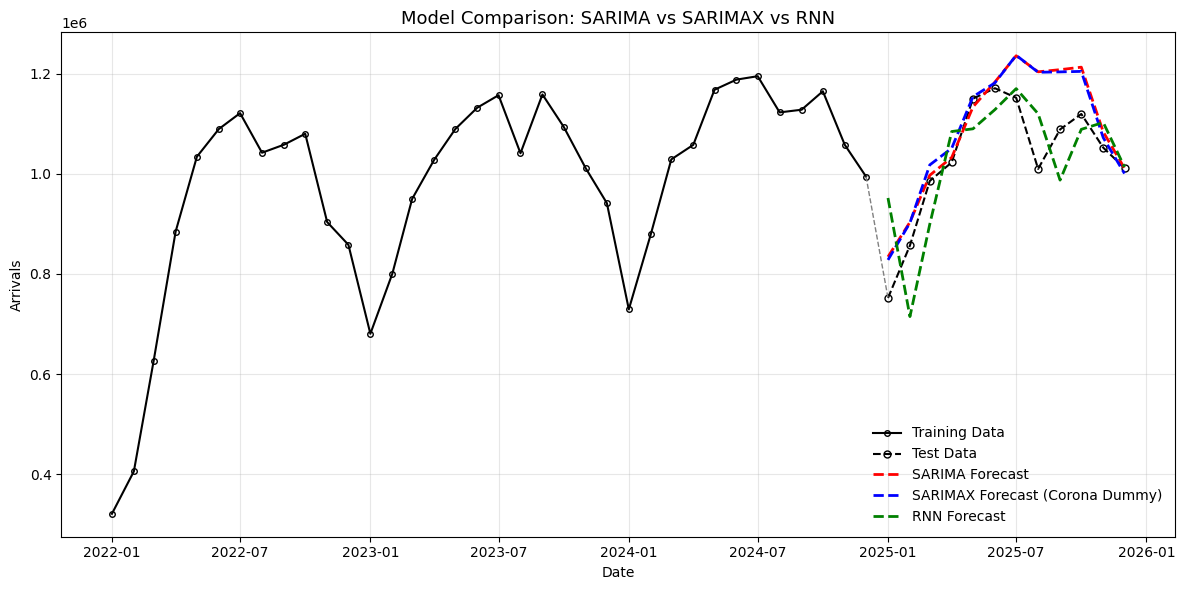

In [248]:
# --------------------------------------------------
# Plot comparison: SARIMA vs SARIMAX vs RNN

plt.figure(figsize=(12,6))

# Training data (last 36 months)
plt.plot(
    u1_ts.index[-36:],
    u1_ts[-36:],
    color="black",
    linewidth=1.5,
    marker="o",
    markersize=4,
    markerfacecolor="none",
    label="Training Data"
)

# Test data
plt.plot(
    u2_ts,
    color="black",
    linestyle="--",
    marker="o",
    markersize=5,
    markerfacecolor="none",
    label="Test Data"
)

# SARIMA forecast
plt.plot(
    sarima_df["predicted_mean"],
    color="red",
    linestyle="--",
    linewidth=2,
    label="SARIMA Forecast"
)

# SARIMAX forecast
plt.plot(
    sarimax_df["predicted_mean"],
    color="blue",
    linestyle="--",
    linewidth=2,
    label="SARIMAX Forecast (Corona Dummy)"
)

# RNN forecast
plt.plot(
    rnn_series,
    color="green",
    linestyle="--",
    linewidth=2,
    label="RNN Forecast"
)

# Connect last train to first test
plt.plot(
    [u1_ts.index[-1], u2_ts.index[0]],
    [u1_ts.iloc[-1], u2_ts.iloc[0]],
    linestyle="--",
    color="gray",
    linewidth=1
)

plt.title("Model Comparison: SARIMA vs SARIMAX vs RNN", fontsize=13)
plt.xlabel("Date")
plt.ylabel("Arrivals")

plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()

plt.show()

In [249]:
# --------------------------------------------------
# Calculate MAE for each model

# SARIMA
sarima_pred = sarima_df["predicted_mean"]
actual = u2_ts

actual, sarima_pred = actual.align(sarima_pred, join="inner")

mae_sarima = np.mean(np.abs(actual - sarima_pred))
mape_sarima = np.mean(np.abs((actual - sarima_pred) / actual)) * 100


# SARIMAX
sarimax_pred = sarimax_df["predicted_mean"]

actual, sarimax_pred = actual.align(sarimax_pred, join="inner")

mae_sarimax = np.mean(np.abs(actual - sarimax_pred))
mape_sarimax = np.mean(np.abs((actual - sarimax_pred) / actual)) * 100


# RNN
actual_rnn = pd.Series(test_data.values[-k:], index=rnn_series.index)

mae_rnn = np.mean(np.abs(actual_rnn - rnn_series))
mape_rnn = np.mean(np.abs((actual_rnn - rnn_series) / actual_rnn)) * 100


# --------------------------------------------------
# Create comparison table

results_table = pd.DataFrame({
    "Model": ["SARIMA", "SARIMAX (Corona Dummy)", "RNN"],
    "MAPE (%)": [mape_sarima, mape_sarimax, mape_rnn],
    "MAE": [mae_sarima, mae_sarimax, mae_rnn]
})


# Round numbers for readability
results_table = results_table.round(2)


# Display table
print("\nModel Comparison Table")
print(results_table)


Model Comparison Table
                    Model  MAPE (%)       MAE
0                  SARIMA      5.82  58501.21
1  SARIMAX (Corona Dummy)      5.86  58781.22
2                     RNN      8.04  75541.99


In [256]:
# --------------------------------------------------
# Create comparison table

results_table = pd.DataFrame({
    "Model": ["SARIMA", "SARIMAX (Corona Dummy)", "RNN"],
    "MAPE (%)": [mape_sarima, mape_sarimax, mape_rnn],
    "MAE": [mae_sarima, mae_sarimax, mae_rnn]
})

# Round numbers
results_table = results_table.round(2)

# Display nicely in Jupyter
results_table

,Model,MAPE (%),MAE
0,SARIMA,5.82,58501.21
1,SARIMAX (Corona Dummy),5.86,58781.22
2,RNN,8.04,75541.99


In [258]:
print(results_table.to_markdown(index=False))

| Model                  |   MAPE (%) |     MAE |
|:-----------------------|-----------:|--------:|
| SARIMA                 |       5.82 | 58501.2 |
| SARIMAX (Corona Dummy) |       5.86 | 58781.2 |
| RNN                    |       8.04 | 75542   |
